# AEMO Multi-Market Battery Trading — Simulation & Evaluation

This notebook runs agents in the **AEMOBatteryTradingEnv** with `multi_market` mode,
logs results (like `test_simrun.ipynb`), and evaluates performance (like `test_eval.ipynb`).

## Sections
1. **Setup** — imports, AEMO data fetch, environment creation
2. **Simulation** — run rule-based and RL agents, save logs to parquet
3. **Evaluation** — load logs, compute metrics, diagnostic plots, action comparison

---
## 1. Setup

In [1]:
import multiprocessing
multiprocessing.set_start_method("spawn", force=True)

import sys, os
sys.path.insert(0, 'src')

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path

In [2]:
from AEMOBatteryEnv import (
    AEMOBatteryTradingEnv,
    AEMODataPreprocessor,
    create_aemo_env_from_data,
)
from aemo_data import (
    fetch_aemo_data_bundle,
    fetch_aemo_unit_dispatch,
    get_available_battery_units,
    get_dispatch_active_battery_units,
    check_aemo_dispatch_availability,
    AEMO_REGIONS,
    FCAS_SERVICES,
)

# --- Configuration ---------------------------------------------------------
REGION = AEMO_REGIONS[2]  # e.g. "QLD1" (index 0=NSW1, 1=QLD1, 2=SA1, 3=TAS1, 4=VIC1)
START_DATE = datetime(2021, 1, 1)
END_DATE   = datetime(2021, 1, 7)      # one week of data
ROOT = Path.cwd().parent
CACHE_DIR  = "data/aemo"
OUTPUT_DIR = ROOT / "data/aemo_sim_output"
EVAL_DIR   = ROOT / "eval_output/aemo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG = "aemo_mm"  # prefix for saved log files

# Optional manual override for dispatch replay unit
DISPATCH_DUID_OVERRIDE = None  # e.g. "LBBG1"
DISPATCH_UNIT_INDEX = 0        # used when override is None (index in displayed battery list)
DISPATCH_APPLY_UNIT_SIZING = True  # if True, use selected DUID capacity/power for dispatch replay env
DISPATCH_FETCH_START_DATE = START_DATE
DISPATCH_FETCH_END_DATE = END_DATE  # reduce this window while debugging if the container is memory constrained

# Environment parameters (default/base)
BATTERY_CAPACITY = 10.0   # MWh
MAX_BATTERY_FLOW = 5.0    # MW
INIT_SOC         = 5.0    # MWh (50 %)
STEP_DURATION    = 5/60    # hours (5-min intervals)
BATTERY_LIFE_COST = 1_000_000.0  # USD

NUM_EPISODES = 3  # number of parallel episodes to collect

print(f"Region: {REGION}")
print(f"Date range: {START_DATE.date()} → {END_DATE.date()}")
print(f"output dir: {OUTPUT_DIR}")

Region: SA1
Date range: 2021-01-01 → 2021-01-07
output dir: /code/data/aemo_sim_output


### 1.1 Fetch & preprocess AEMO data

In [3]:
# Fetch raw AEMO data (prices, FCAS, generation)
raw_data = fetch_aemo_data_bundle(
    start_date=START_DATE,
    end_date=END_DATE,
    region=REGION,
    fcas_services=["RAISEREG", "LOWERREG", "RAISE6SEC", "LOWER6SEC",
                   "RAISE60SEC", "LOWER60SEC", "RAISE5MIN", "LOWER5MIN"],
    fuel_types=["solar", "wind"],
    cache_dir=CACHE_DIR,
)

preprocessor = AEMODataPreprocessor(step_duration_hours=STEP_DURATION)
processed_data = preprocessor.preprocess_aemo_data(
    prices=raw_data["prices"],
    fcas=raw_data["fcas"],
    generation=raw_data["generation"],
)
print(f"Processed data: {processed_data.height} rows, {processed_data.width} cols")
print(f"Columns: {processed_data.columns}")

Fetching AEMO data bundle for SA1 from 2021-01-01 to 2021-01-07...
Fetching dispatch price data for SA1 from 2021-01-01 to 2021-01-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Returning DISPATCHREGIONSUM.
Fetched 1728 price records
Fetching FCAS RAISEREG price data for SA1 from 2021-01-01 to 2021-01-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 1728 FCAS price records
Fetching FCAS LOWERREG price data for SA1 from 2021-01-01 to 2021-01-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 1728 FCAS price records
Fetching FCAS RAISE6SEC price data for SA1 from 2021-01-01 to 2021-01-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 1728 FCAS price records
Fetching FCAS LOWER6SEC price data for SA1 from 2021-01-01 to 2021-01-07...
INFO: Compiling data for table DISPATCHPRICE
INFO:

### 1.2 Create multi-market environments

We create several independent environments (different random episode start indices on reset)
so we can collect multiple episodes in parallel — just like `test_simrun.ipynb` does
with household data.

In [ ]:

# Each env is an independent instance sharing the same preprocessed data
envs = [
    AEMOBatteryTradingEnv(
        aemo_data=processed_data,
        battery_capacity=BATTERY_CAPACITY,
        max_battery_flow=MAX_BATTERY_FLOW,
        init_battery_level=INIT_SOC,
        max_step=288,               # ~3 days at 30-min resolution
        step_duration=STEP_DURATION,
        battery_life_cost=BATTERY_LIFE_COST,
        action_mode="multi_market",
        degradation_mode="rainflow",
    )
    for _ in range(NUM_EPISODES)
]

print(f"Created {len(envs)} multi-market AEMO environments")
print(f"Obs space : {envs[0].observation_space}")
print(f"Act space : {envs[0].action_space}  (energy_dispatch, fcas_raise, fcas_lower)")

Created 3 multi-market AEMO environments
Obs space : Box([-1. -1. -1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.], 1.0, (18,), float32)
Act space : Box([-1.  0.  0.], 1.0, (3,), float32)  (energy_dispatch, fcas_raise, fcas_lower)


/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


---
## 2. Simulation — run agents & save logs

We run the same agent algorithms used in `test_simrun.ipynb`, adapted for the AEMO env.

### 2.1 Rule-based agent

In [ ]:
from decision import AEMOAgent, run_episodes_parallel

agent_kwargs_list = [
    {
        "algorithm": "rule",
        "reset_options": {"random_episode_start": True},
        "reset_seed": 1000 + i,   # optional; remove for non-reproducible random starts
    }
    for i in range(NUM_EPISODES)
]

rule_episode_logs, rule_incident_logs = run_episodes_parallel(
    AEMOAgent,
    envs,
    agent_kwargs=agent_kwargs_list,
    render=False,
    max_workers=NUM_EPISODES,
    use_notebook_tqdm=True,
)

In [ ]:
# Save rule agent logs
dfs_with_id = [
    df.with_columns(pl.lit(i).alias("episode_id"))
    for i, df in enumerate(rule_episode_logs)
]
rule_all_logs = pl.concat(dfs_with_id)

file_name = OUTPUT_DIR / f"{RUN_TAG}_rule_logs.parquet"
rule_all_logs.write_parquet(str(file_name))
print(f"Saved rule logs → {file_name}  ({rule_all_logs.height} rows)")

# Incident logs
incident_dfs = [
    df.with_columns(pl.lit(i).alias("episode_id"))
    for i, df in enumerate(rule_incident_logs)
    if df.height > 0
]
if incident_dfs:
    rule_inc = pl.concat(incident_dfs)
    inc_file = OUTPUT_DIR / f"{RUN_TAG}_rule_incident_logs.parquet"
    rule_inc.write_parquet(str(inc_file))
    print(f"Saved incident logs → {inc_file}")
else:
    print("[INFO] No incident logs to save.")

### 2.2 Dispatch replay agent (unit DUID from static table)

This section lists available battery units from the AEMO static table and supports two selectors:
- `DISPATCH_DUID_OVERRIDE` for explicit DUID selection (also accepts a station name, e.g. `"hornsdale"`)
- `DISPATCH_UNIT_INDEX` for index-based selection from the displayed list

You can also query by **station name** to automatically use the correct historical DUID for any date
range.  Use `list_known_batteries()` to see all registered batteries and their DUID histories.

Example — query Hornsdale Power Reserve for a pre-transition date range:
```python
# Automatically resolves to HPRG1/HPRL1 before Oct 2022, HPR1 after
battery_units, active_units = show_dispatch_candidates(station_name="hornsdale")
```

If `DISPATCH_APPLY_UNIT_SIZING=True`, the dispatch replay environment adopts selected-unit sizing
(capacity and max MW where available), while rule/RL sections keep the base environment settings.

> **Memory / kernel crash note**: For date windows longer than ~1 month, data is automatically
> fetched using an efficient per-DUID filter to avoid loading the full ~850 K-row DISPATCHLOAD
> table into memory each month.  If you still see memory issues, reduce the date window or use
> `station_name` to narrow the query to a single battery.

In [4]:
# --- Dispatch replay helpers -------------------------------------------------
from dispatch_utils import (
    list_known_batteries,
    show_dispatch_table,
    list_dispatch_candidates,
    resolve_dispatch_selection,
    run_dispatch_replay,
)

# original versions relied on notebook globals; wrap to keep that behaviour

def show_dispatch_candidates(station_name=None):
    return list_dispatch_candidates(
        region=REGION,
        start_date=DISPATCH_FETCH_START_DATE,
        end_date=DISPATCH_FETCH_END_DATE,
        station_name=station_name,
        cache_dir=CACHE_DIR,
    )

from decision import AEMOAgent, run_single

# globals used by later cells
dispatch_episode_logs = []
dispatch_incident_logs = []
DISPATCH_DUID = None
DISPATCH_DUID_GEN = None
DISPATCH_DUID_LOAD = None
DISPATCH_TYPE = None


### 2.2.1 Inspect available and dispatch-active DUIDs

Run the cells below to:
1. List all batteries in the built-in registry (with historical DUID mappings).
2. Print the static battery list and the subset active in `DISPATCHLOAD` for the selected date range.

Use the output to choose the DUID or station name you want to replay.

In [5]:
# Show all registered batteries with their historical DUID mappings.
# The "Key" column is a short name you can pass to show_dispatch_candidates(station_name=...).
battery_station_list = list_known_batteries()

In [6]:
# all rows for the selected region, unique station keys/names
region_stations = battery_station_list.filter(pl.col("Region") == REGION)
print(region_stations.select(["Key","StationName","ValidFrom","ValidUntil"]).unique())

# or, if you only care about the keys you can do
print(region_stations["Key"].unique().to_list())

shape: (9, 4)
┌─────────────────┬─────────────────────────────────┬─────────────────────┬─────────────────────┐
│ Key             ┆ StationName                     ┆ ValidFrom           ┆ ValidUntil          │
│ ---             ┆ ---                             ┆ ---                 ┆ ---                 │
│ str             ┆ str                             ┆ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════╪═════════════════════════════════╪═════════════════════╪═════════════════════╡
│ lake_bonney     ┆ Lake Bonney BESS1               ┆ 2022-06-01 00:00:00 ┆ null                │
│ bungama         ┆ Bungama Battery Energy Storage… ┆ 2023-06-01 00:00:00 ┆ null                │
│ hornsdale       ┆ Hornsdale Power Reserve         ┆ 2017-12-01 00:00:00 ┆ 2022-10-01 00:00:00 │
│ dalrymple_north ┆ Dalrymple North BESS            ┆ 2023-01-01 00:00:00 ┆ null                │
│ hornsdale       ┆ Hornsdale Power Reserve         ┆ 2022-10-01 00:00:00 ┆ null                │
│ blyt

In [7]:
# Example: query Hornsdale Power Reserve for 2021
# (pre-transition period — automatically uses HPRG1 + HPRL1)
battery_units, active_units = show_dispatch_candidates(station_name="hornsdale")


Station: 'Hornsdale Power Reserve' (SA1)
DUIDs active in 2021-01-01 → 2021-01-07: ['HPRG1', 'HPRL1']
Fetching unit dispatch data for 2 DUIDs from 2021-01-01 to 2021-01-07...
INFO: Compiling data for table DISPATCHLOAD
INFO: Returning DISPATCHLOAD.
Fetched 3456 dispatch records for 2 unique units

Dispatch data for 'Hornsdale Power Reserve'
shape: (2, 10)
┌───────┬────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ DUID  ┆ Region ┆ DispatchTy ┆ NonZeroInt ┆ … ┆ FirstDispa ┆ LastDispat ┆ PairedGenD ┆ PairedLoad │
│ ---   ┆ ---    ┆ pe         ┆ ervalCount ┆   ┆ tchInterva ┆ chInterval ┆ UID        ┆ DUID       │
│ str   ┆ str    ┆ ---        ┆ ---        ┆   ┆ l          ┆ ---        ┆ ---        ┆ ---        │
│       ┆        ┆ str        ┆ u32        ┆   ┆ ---        ┆ datetime[μ ┆ str        ┆ str        │
│       ┆        ┆            ┆            ┆   ┆ datetime[μ ┆ s]         ┆            ┆            │
│       ┆        ┆            ┆      

In [8]:
# Show active DUIDs for the selected station (or region query)
if active_units is not None and active_units.height > 0:
    print("Active DUIDs:", active_units["DUID"].to_list())
else:
    print("No active units found for the selected station/region and date range.")


Active DUIDs: ['HPRG1', 'HPRL1']


### 2.2.2 Run a selected dispatch replay DUID

Set `SELECTED_DISPATCH_STATION` to a station name (e.g. `"hornsdale"`, `"lake_bonney"`, `"torrens_island"`) to automatically use the correct historical DUID for the configured date range.  Alternatively, set `SELECTED_DISPATCH_DUID` to an explicit DUID string.

**Station-name workflow** (recommended):
```python
SELECTED_DISPATCH_STATION = "hornsdale"   # will auto-resolve to HPR1 / HPRG1+HPRL1
```

**Explicit DUID workflow**:
```python
SELECTED_DISPATCH_DUID = "HPR1"          # must be valid for the configured date range
```

Leave both as `None` / `""` to use `SELECTED_DISPATCH_INDEX` to pick by row position from the dispatch-active table printed above.

In [9]:
# ---------------------------------------------------------------
# Choose how to select the dispatch unit for replay:
#   1. Station name (recommended) — auto-resolves historical DUIDs
#   2. Explicit DUID string
#   3. Row index from the active-units table above
# ---------------------------------------------------------------

# Option 1: station name (e.g. "hornsdale", "lake_bonney", "torrens_island")
SELECTED_DISPATCH_STATION = "hornsdale"   # set to None to skip

# Option 2: explicit DUID (e.g. "HPR1", "HPRG1").  Set to None to use station or index.
SELECTED_DISPATCH_DUID = None

# Option 3: row index from the dispatch-active table (ignored when option 1 or 2 is set)
SELECTED_DISPATCH_INDEX = DISPATCH_UNIT_INDEX

# ------------------------------------------------------------------
# If a station name is given, re-run list_dispatch_candidates to get
# the correct battery_units / active_units for the station so that
# resolve_dispatch_selection can pick up PairedGenDUID / PairedLoadDUID.
# ------------------------------------------------------------------
_resolve_duid = SELECTED_DISPATCH_DUID
if SELECTED_DISPATCH_STATION:
    _station_battery_units, _station_active_units = list_dispatch_candidates(
        region=REGION,
        start_date=DISPATCH_FETCH_START_DATE,
        end_date=DISPATCH_FETCH_END_DATE,
        station_name=SELECTED_DISPATCH_STATION,
        cache_dir=CACHE_DIR,
    )
    if _station_active_units is not None and _station_active_units.height > 0:
        battery_units = _station_battery_units
        active_battery_units = _station_active_units
        # Use the primary active DUID from the registry for this period
        from aemo_data import resolve_battery_duids
        _res = resolve_battery_duids(SELECTED_DISPATCH_STATION, DISPATCH_FETCH_START_DATE, DISPATCH_FETCH_END_DATE)
        if _res["found"]:
            # Prefer bidi DUID, fall back to gen DUID
            _resolve_duid = _resolve_duid or _res["bidi_duid"] or _res["gen_duid"] or (
                _res["all_duids_in_range"][0] if _res["all_duids_in_range"] else None
            )
    else:
        print("[WARN] Station query returned no active units — falling back to region-based table.")

selection = resolve_dispatch_selection(
    battery_units=battery_units,
    active_battery_units=_station_active_units,
    selected_duid=_resolve_duid,
    selected_index=SELECTED_DISPATCH_INDEX,
    battery_capacity=BATTERY_CAPACITY,
    max_battery_flow=MAX_BATTERY_FLOW,
    init_soc=INIT_SOC,
    apply_unit_sizing=DISPATCH_APPLY_UNIT_SIZING,
    start_date=DISPATCH_FETCH_START_DATE,
    end_date=DISPATCH_FETCH_END_DATE,
    cache_dir=CACHE_DIR,
)

dispatch_episode_logs, dispatch_incident_logs, dispatch_all_logs = run_dispatch_replay(
    processed_data=processed_data,
    selection=selection,
    start_date=DISPATCH_FETCH_START_DATE,
    end_date=DISPATCH_FETCH_END_DATE,
    region=REGION,
    cache_dir=CACHE_DIR,
    num_episodes=NUM_EPISODES,
    step_duration=STEP_DURATION,
    battery_life_cost=BATTERY_LIFE_COST,
    output_dir=str(OUTPUT_DIR),
    run_tag=RUN_TAG,
)

print(f"\nSelection summary: DUID={selection['duid']!r}, "
      f"gen={selection['dispatch_duid_gen']!r}, load={selection['dispatch_duid_load']!r}")
selection


Station: 'Hornsdale Power Reserve' (SA1)
DUIDs active in 2021-01-01 → 2021-01-07: ['HPRG1', 'HPRL1']
Fetching unit dispatch data for 2 DUIDs from 2021-01-01 to 2021-01-07...
INFO: Compiling data for table DISPATCHLOAD
INFO: Returning DISPATCHLOAD.
Fetched 3456 dispatch records for 2 unique units

Dispatch data for 'Hornsdale Power Reserve'
shape: (2, 10)
┌───────┬────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ DUID  ┆ Region ┆ DispatchTy ┆ NonZeroInt ┆ … ┆ FirstDispa ┆ LastDispat ┆ PairedGenD ┆ PairedLoad │
│ ---   ┆ ---    ┆ pe         ┆ ervalCount ┆   ┆ tchInterva ┆ chInterval ┆ UID        ┆ DUID       │
│ str   ┆ str    ┆ ---        ┆ ---        ┆   ┆ l          ┆ ---        ┆ ---        ┆ ---        │
│       ┆        ┆ str        ┆ u32        ┆   ┆ ---        ┆ datetime[μ ┆ str        ┆ str        │
│       ┆        ┆            ┆            ┆   ┆ datetime[μ ┆ s]         ┆            ┆            │
│       ┆        ┆            ┆      

/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


INFO: Returning DISPATCHLOAD.
Fetched 1728 dispatch records for 1 unique units
Dispatch rows fetched for HPRG1: 1728
shape: (5, 11)
┌─────────────┬───────┬────────────┬───────────┬───┬───────────┬────────────┬───────────┬──────────┐
│ SETTLEMENTD ┆ DUID  ┆ TOTALCLEAR ┆ RAISE6SEC ┆ … ┆ LOWER6SEC ┆ LOWER60SEC ┆ LOWER5MIN ┆ LOWERREG │
│ ATE         ┆ ---   ┆ ED         ┆ ---       ┆   ┆ ---       ┆ ---        ┆ ---       ┆ ---      │
│ ---         ┆ str   ┆ ---        ┆ f64       ┆   ┆ f64       ┆ f64        ┆ f64       ┆ f64      │
│ datetime[ns ┆       ┆ f64        ┆           ┆   ┆           ┆            ┆           ┆          │
│ ]           ┆       ┆            ┆           ┆   ┆           ┆            ┆           ┆          │
╞═════════════╪═══════╪════════════╪═══════════╪═══╪═══════════╪════════════╪═══════════╪══════════╡
│ 2021-01-01  ┆ HPRL1 ┆ 0.0        ┆ 0.0       ┆ … ┆ 78.82947  ┆ 27.0       ┆ 49.78703  ┆ 70.21297 │
│ 00:05:00    ┆       ┆            ┆           ┆   ┆        

{'duid': 'HPRG1',
 'dispatch_type': 'generator',
 'dispatch_duid_gen': None,
 'dispatch_duid_load': 'HPRL1',
 'battery_capacity': 10.0,
 'max_battery_flow': 5.0,
 'init_battery_level': 5.0,
 'availability': {'duid': 'HPRG1',
  'start_date': datetime.datetime(2021, 1, 1, 0, 0),
  'end_date': datetime.datetime(2021, 1, 7, 0, 0),
  'has_data': True,
  'row_count': 1728,
  'unique_intervals': 1728,
  'expected_intervals': 1728,
  'coverage_ratio': 1.0,
  'months_checked': 1,
  'months_with_data': 1,
  'first_settlement': datetime.datetime(2021, 1, 1, 0, 5),
  'last_settlement': datetime.datetime(2021, 1, 7, 0, 0)}}

### 2.2.3 Visualise dispatch replay episode

Use `EpisodeVisualizer()` to inspect the first dispatch replay episode, either from the in-memory `dispatch_episode_logs` list or from a saved parquet log if you rerun the notebook later.

Using in-memory dispatch episode logs.
shape: (5, 3)
┌──────┬─────────────────┬───────────┐
│ step ┆ action          ┆ reward    │
│ ---  ┆ ---             ┆ ---       │
│ i64  ┆ list[f32]       ┆ f64       │
╞══════╪═════════════════╪═══════════╡
│ 0    ┆ [0.0, 0.0, 1.0] ┆ 0.0058125 │
│ 1    ┆ [0.0, 0.0, 1.0] ┆ 0.0054125 │
│ 2    ┆ [0.0, 0.0, 1.0] ┆ 0.004529  │
│ 3    ┆ [1.0, 1.0, 1.0] ┆ -0.004931 │
│ 4    ┆ [0.4, 0.0, 1.0] ┆ -0.000595 │
└──────┴─────────────────┴───────────┘


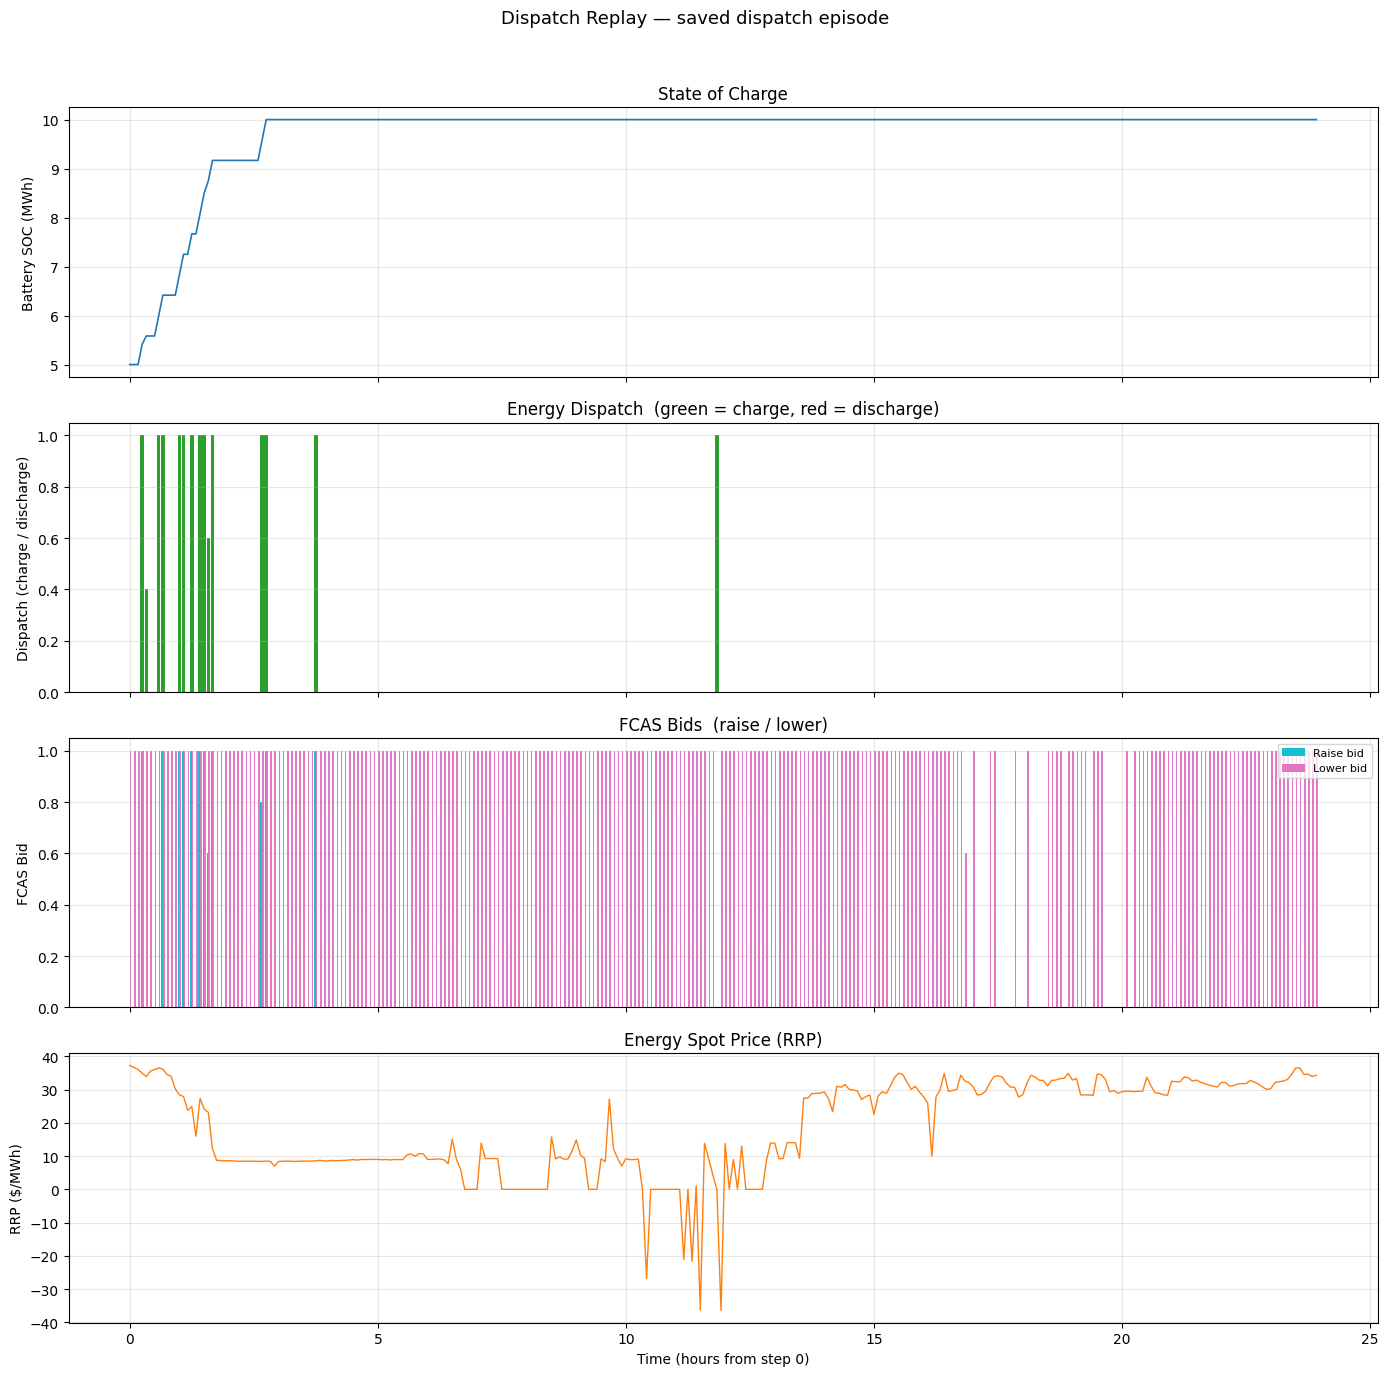

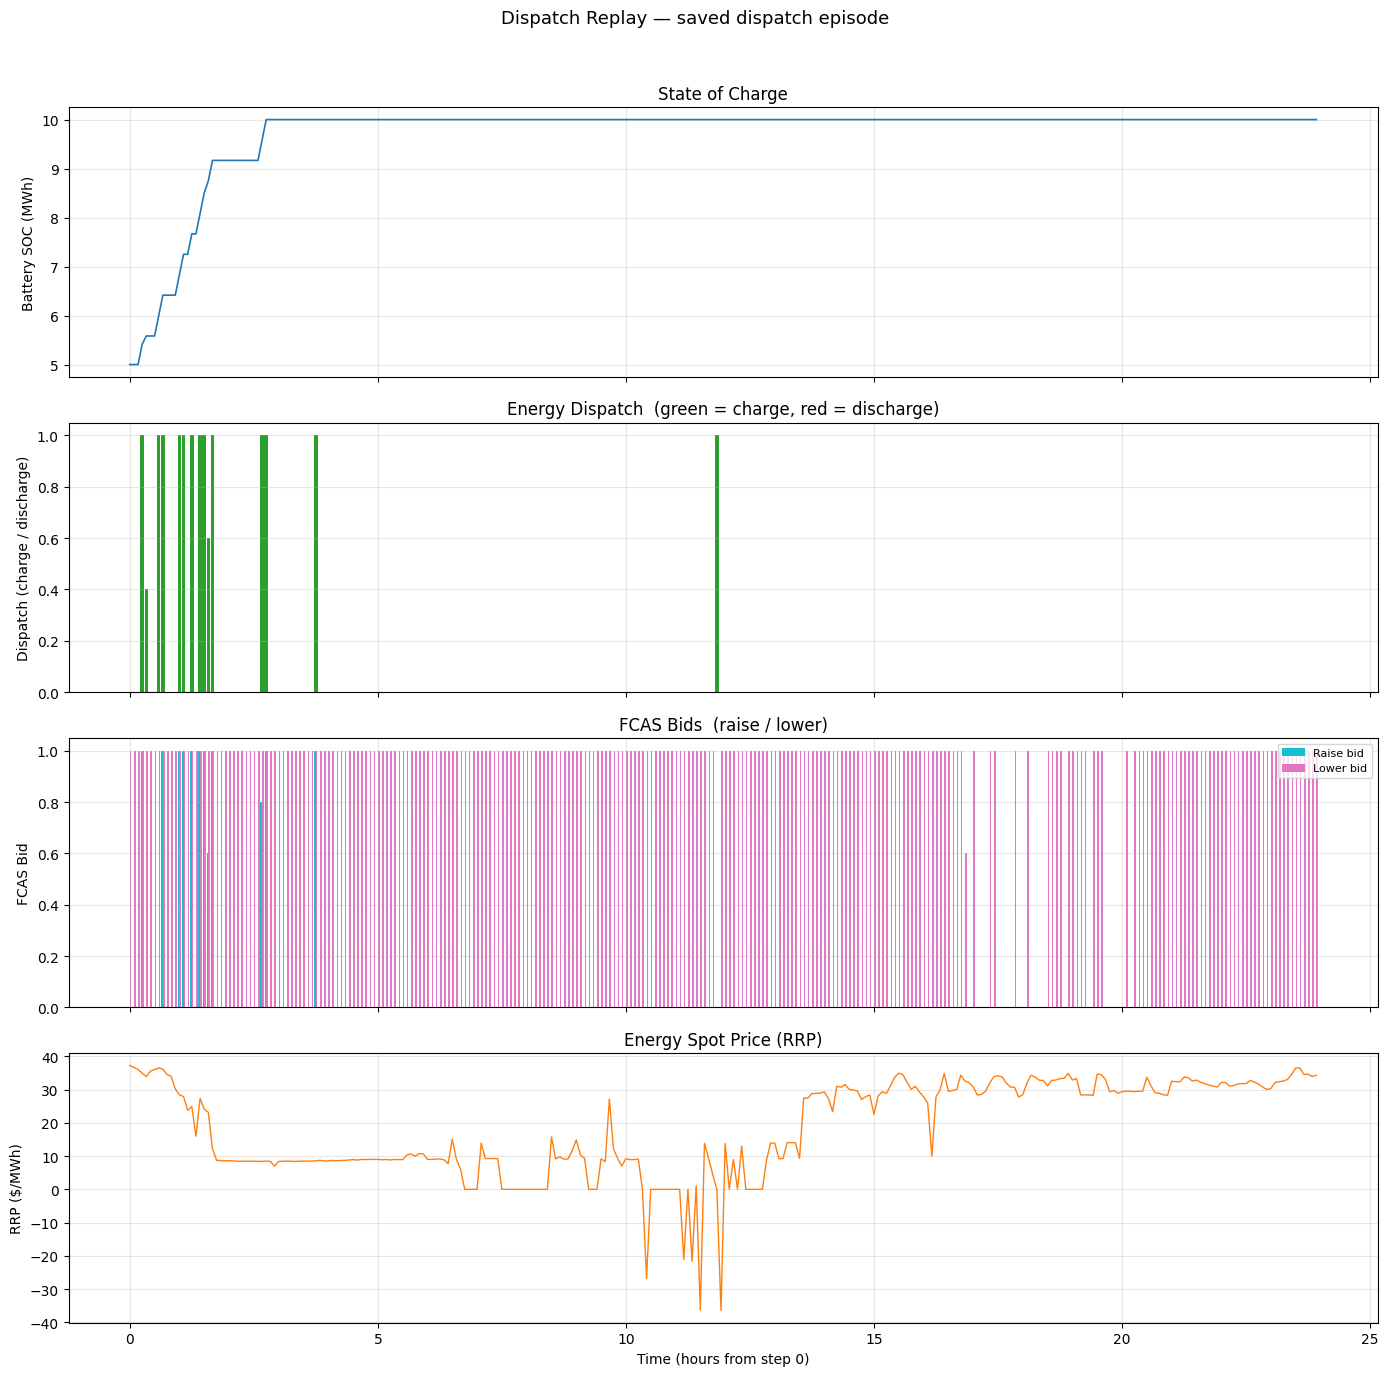

In [10]:
from helper import EpisodeVisualizer

def load_dispatch_episode_for_visualization():
    if "dispatch_episode_logs" in globals() and len(dispatch_episode_logs) > 0:
        print("Using in-memory dispatch episode logs.")
        return dispatch_episode_logs[0]

    candidate_paths = [
        OUTPUT_DIR / f"{RUN_TAG}_dispatch_logs.parquet",
        ROOT / "data/aemo_sim_output" / f"{RUN_TAG}_dispatch_logs.parquet",
        ROOT / "src/data/aemo_sim_output" / f"{RUN_TAG}_dispatch_logs.parquet",
    ]

    for path in candidate_paths:
        if path.exists():
            print(f"Loading saved dispatch logs from {path}")
            df = pl.read_parquet(str(path))
            if "episode_id" in df.columns:
                episode_ids = sorted(df["episode_id"].unique().to_list())
                if not episode_ids:
                    raise ValueError(f"No episode_id values found in {path}")
                return df.filter(pl.col("episode_id") == episode_ids[0]).drop("episode_id")
            return df

    raise FileNotFoundError(
        "No dispatch episode logs found in memory or on disk. "
        "Run the dispatch replay cell first."
    )

dispatch_vis_df = load_dispatch_episode_for_visualization()
print(dispatch_vis_df.select([c for c in ["step", "action", "reward"] if c in dispatch_vis_df.columns]).head(5))

dispatch_vis = EpisodeVisualizer(
    dispatch_vis_df,
    step_duration=STEP_DURATION,
    env_type="aemo",
)
dispatch_fig = dispatch_vis.plot(
    start_step=0,
    num_hours=min(48.0, max(STEP_DURATION, dispatch_vis_df.height * STEP_DURATION)),
    title=f"Dispatch Replay — {DISPATCH_DUID or 'saved dispatch episode'}",
    x_axis_mode="elapsed",
    show=True,
 )
dispatch_fig

### 2.3 SB3 RL agents (optional — requires trained models)

If you have SB3 models trained on the AEMO env, load and evaluate them here.
Otherwise this section is skipped gracefully.

In [ ]:
from decision import AEMOAgent, run_single

# --- Attempt to load SB3 models trained on AEMO multi-market env -----------
rl_models = {}  # label -> (model, algorithm_name)

try:
    from stable_baselines3 import PPO, SAC, A2C, DDPG, TD3

    model_candidates = {
        "sac":  (SAC,  "models/aemo_sac_model.zip"),
        "ppo":  (PPO,  "models/aemo_ppo_model.zip"),
        "a2c":  (A2C,  "models/aemo_a2c_model.zip"),
        "ddpg": (DDPG, "models/aemo_ddpg_model.zip"),
        "td3":  (TD3,  "models/aemo_td3_model.zip"),
    }

    for label, (cls, path) in model_candidates.items():
        if os.path.exists(path):
            model = cls.load(path)
            rl_models[label] = model
            print(f"Loaded {label.upper()} from {path}")
        else:
            print(f"[SKIP] {path} not found")
except ImportError:
    print("[SKIP] stable-baselines3 not installed")

print(f"\nRL models available: {list(rl_models.keys()) or 'none'}")

In [ ]:
# Run each RL model as an AEMOAgent with algorithm='rl'
rl_all_episode_logs = {}  # label -> list[pl.DataFrame]

for label, model in rl_models.items():
    print(f"\n--- Running {label.upper()} agent ---")
    ep_logs = []
    for idx, env in enumerate(envs):
        agent_kwargs = {"algorithm": "rl", "model": model}
        ep_df, inc_df = run_single(AEMOAgent, env, agent_kwargs=agent_kwargs, render=False)
        ep_logs.append(ep_df)
        print(f"  Episode {idx}: {ep_df.height} steps, reward={ep_df['reward'].sum():.2f}")

    rl_all_episode_logs[label] = ep_logs

    # Save logs
    dfs_with_id = [df.with_columns(pl.lit(i).alias("episode_id")) for i, df in enumerate(ep_logs)]
    combined = pl.concat(dfs_with_id)
    out_file = OUTPUT_DIR / f"{RUN_TAG}_{label}_logs.parquet"
    combined.write_parquet(str(out_file))
    print(f"  Saved → {out_file}  ({combined.height} rows)")

if not rl_models:
    print("No RL models to run. Continuing with rule-based logs only.")

---
## 3. Evaluation

This section mirrors `test_eval.ipynb` — load all collected logs, compute metrics,
run diagnostics, and produce comparison plots.

### 3.1 Load logs into the evaluation dict

In [ ]:
import re

# Build the all_logs dict: label -> list[pl.DataFrame]  (one DF per episode)
# Start with already-in-memory logs from this session
all_logs: dict[str, list[pl.DataFrame]] = {}

# Rule logs (always present)
all_logs["rule"] = rule_episode_logs

# Dispatch logs (if collected)
if "dispatch_episode_logs" in globals() and len(dispatch_episode_logs) > 0:
    all_logs["dispatch"] = dispatch_episode_logs

# RL logs (if any were run)
all_logs.update(rl_all_episode_logs)

# Optionally, scan the output directory for previously saved parquet logs
for f in sorted(OUTPUT_DIR.glob(f"{RUN_TAG}_*_logs.parquet")):
    fname = f.stem  # e.g. aemo_mm_rule_logs
    # extract the algorithm label between the tag prefix and _logs suffix
    m = re.match(rf"^{re.escape(RUN_TAG)}_(.+?)_logs$", fname)
    if not m:
        continue
    label = m.group(1)
    if label in all_logs:
        continue  # already loaded from memory
    try:
        df = pl.read_parquet(str(f))
        if df.height == 0:
            continue
        if "episode_id" not in df.columns:
            df = df.with_columns(pl.lit(0).alias("episode_id"))
        eps = [df.filter(pl.col("episode_id") == eid) for eid in df["episode_id"].unique()]
        all_logs[label] = eps
        print(f"Loaded {label} from {f.name}: {len(eps)} episodes, {df.height} rows")
    except Exception as e:
        print(f"[WARN] Failed to load {f.name}: {e}")

print(f"\nAll labels: {list(all_logs.keys())}")
for lbl, eps in all_logs.items():
    print(f"  {lbl}: {len(eps)} episodes")

### 3.2 Problematic-episode diagnostics

In [ ]:
from helper import find_problematic_episodes

problems, suggested_return_scale = find_problematic_episodes(all_logs)
print(f"Suggested return scale: {suggested_return_scale}")
print(f"Problematic episodes found: {len(problems)}")

for p in problems[:10]:  # show first 10
    print(p)

### 3.3 Evaluate experiments — metrics & plots

In [ ]:
from helper import evaluate_experiments

metrics = evaluate_experiments(
    all_logs,
    target_return=0.0,
    save_dir=str(EVAL_DIR),
)

# Save metrics CSV
metrics_csv = EVAL_DIR / "evaluation_metrics.csv"
metrics.write_csv(str(metrics_csv))
print(f"Saved evaluation metrics → {metrics_csv}")
metrics

In [ ]:
# Print rankings
import pandas as pd

mdf = metrics.to_pandas().set_index("experiment")

print("Mean reward ranking (higher is better):")
print(mdf["mean_reward"].sort_values(ascending=False))

if "sharpe_ratio" in mdf.columns:
    print("\nSharpe ratio ranking (higher is better):")
    print(mdf["sharpe_ratio"].sort_values(ascending=False))

### 3.4 Per-episode inspection

In [ ]:
# Pick the first algorithm & first episode for a quick visual inspection
inspect_algo = list(all_logs.keys())[0]
inspect_ep   = 0

df = all_logs[inspect_algo][inspect_ep]
print(f"Inspecting: {inspect_algo}, episode {inspect_ep}  ({df.height} steps)")

# Extract info-dict fields if present
def extract_info_field(df, field):
    """Safely extract a field from the info column (dict or JSON string)."""
    import json, ast
    vals = []
    for info in df["info"]:
        if info is None:
            vals.append(None)
        elif isinstance(info, dict):
            vals.append(info.get(field))
        else:
            try:
                j = json.loads(info) if isinstance(info, str) else info
                vals.append(j.get(field) if isinstance(j, dict) else None)
            except Exception:
                try:
                    j = ast.literal_eval(info)
                    vals.append(j.get(field) if isinstance(j, dict) else None)
                except Exception:
                    vals.append(None)
    return vals

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Rewards
axes[0].plot(df["reward"].to_list(), linewidth=0.8)
axes[0].set_ylabel("Reward")
axes[0].set_title(f"{inspect_algo} — Episode {inspect_ep}")
axes[0].grid(alpha=0.3)

# SOC
soc_vals = extract_info_field(df, "battery_soc")
axes[1].plot(soc_vals, linewidth=0.8, color="tab:green")
axes[1].set_ylabel("Battery SOC (MWh)")
axes[1].grid(alpha=0.3)

# Energy price
price_vals = extract_info_field(df, "energy_price")
axes[2].plot(price_vals, linewidth=0.8, color="tab:orange")
axes[2].set_ylabel("Energy Price ($/MWh)")
axes[2].grid(alpha=0.3)

# Actions
actions = df["action"].to_list()
if actions and isinstance(actions[0], list):
    energy_actions = [a[0] for a in actions]
    axes[3].plot(energy_actions, linewidth=0.8, label="energy dispatch")
    if len(actions[0]) >= 3:
        axes[3].plot([a[1] for a in actions], linewidth=0.8, alpha=0.6, label="FCAS raise bid")
        axes[3].plot([a[2] for a in actions], linewidth=0.8, alpha=0.6, label="FCAS lower bid")
    axes[3].legend(fontsize=8)
else:
    axes[3].plot(actions, linewidth=0.8)
axes[3].set_ylabel("Action")
axes[3].set_xlabel("Step")
axes[3].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(str(EVAL_DIR / "episode_inspection.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved episode inspection plot → {EVAL_DIR / 'episode_inspection.png'}")

### 3.5 Degradation analysis

In [ ]:
# Plot degradation metrics from the info dict
deg_vals = extract_info_field(df, "step_degradation")
total_deg = extract_info_field(df, "total_degradation")
cap_vals  = extract_info_field(df, "capacity_mwh")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(deg_vals, linewidth=0.8, color="tab:red")
axes[0].set_ylabel("Step Degradation")
axes[0].set_title(f"Degradation — {inspect_algo} ep {inspect_ep}")
axes[0].grid(alpha=0.3)

axes[1].plot(total_deg, linewidth=0.8, color="tab:purple")
axes[1].set_ylabel("Cumulative Degradation")
axes[1].grid(alpha=0.3)

axes[2].plot(cap_vals, linewidth=0.8, color="tab:blue")
axes[2].set_ylabel("Capacity (MWh)")
axes[2].set_xlabel("Step")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.6 Action comparison (pairwise vs reference)

In [ ]:
# Only run action comparison if we have more than one algorithm
if len(all_logs) > 1:
    from helper import AlgorithmActionComparator, ActionComparisonConfig

    def compare_action_pairwise_to_reference(
        logs_dict, reference, base_save_dir=None, **kwargs
    ):
        comparator = AlgorithmActionComparator(action_logs=logs_dict)
        results = {}
        for algo in logs_dict:
            if algo == reference:
                continue
            sub_logs = {reference: logs_dict[reference], algo: logs_dict[algo]}
            kw = dict(kwargs)
            if base_save_dir:
                out = Path(base_save_dir) / f"{reference}_vs_{algo}"
                out.mkdir(parents=True, exist_ok=True)
                kw["save_dir"] = str(out)
            cfg = ActionComparisonConfig(reference=reference, **kw)
            results[algo] = comparator.compare(logs_dict=sub_logs, config=cfg)
        return results

    pairwise_results = compare_action_pairwise_to_reference(
        all_logs,
        reference="rule",
        base_save_dir=str(EVAL_DIR),
        bins="auto",
        max_episodes=20,
    )
    print("Pairwise comparison complete for:", list(pairwise_results.keys()))
else:
    print("Only one algorithm available — skipping pairwise action comparison.")

### 3.7 Temporal analysis (optional)

In [ ]:
# Temporal analysis on a single episode across algorithms
if len(all_logs) > 1:
    from helper import AlgorithmActionComparator, TemporalAnalysisConfig

    # Pick episode 0 from each algorithm for temporal overlay
    episode_single = {}
    for algo, logs in all_logs.items():
        if len(logs) > 0:
            episode_single[algo] = logs[0]

    if len(episode_single) > 1:
        steps_per_hour = int(1 / STEP_DURATION)
        two_day_steps = 2 * 24 * steps_per_hour

        time_periods = [
            (0, min(two_day_steps, min(df.height for df in episode_single.values()))),
        ]

        comparator = AlgorithmActionComparator()
        cfg = TemporalAnalysisConfig(
            time_periods=time_periods,
            annotate_states=True,
            step_duration=STEP_DURATION,
            reference="rule",
            action_tolerance=0.01,
            save_path=str(EVAL_DIR / "temporal"),
        )
        result = comparator.analyze_temporal(logs_dict=episode_single, config=cfg)
        print(result.stats)
        plt.show(result.figure)
    else:
        print("Need at least 2 algorithms for temporal comparison.")
else:
    print("Only one algorithm — skipping temporal analysis.")

---
## Summary

This notebook demonstrated the complete AEMO multi-market simulation and evaluation pipeline:

1. **Data** — Fetched and preprocessed AEMO NEM data (prices, FCAS, generation)
2. **Simulation** — Ran rule-based (and optionally RL) agents on `AEMOBatteryTradingEnv` in `multi_market` mode, logged to parquet
3. **Evaluation** — Computed performance metrics, diagnostic plots, action comparisons, and degradation analysis

### Next steps
- Train SB3 agents (PPO, SAC) on the multi-market AEMO environment
- Fine-tune a Decision Transformer on AEMO episode data
- Compare dispatch-replay agents against RL and rule-based baselines
- Analyse FCAS revenue contribution vs energy arbitrage